In [ ]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv("/content/StudentPerformanceFactors.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.preprocessing import LabelEncoder

le1 = LabelEncoder()
le2 = LabelEncoder()
le3=LabelEncoder()
le4=LabelEncoder()
le5=LabelEncoder()
le6=LabelEncoder()
le7=LabelEncoder()
l8=LabelEncoder()
l9=LabelEncoder()
l10=LabelEncoder()

data["Motivation_Level"] = le1.fit_transform(
    data["Motivation_Level"]
)

data["Parental_Involvement"] = le2.fit_transform(
    data["Parental_Involvement"]
)

data["Extracurricular_Activities"] = le3.fit_transform(
    data["Extracurricular_Activities"]
)

data["Access_to_Resources"] = le4.fit_transform(
    data["Access_to_Resources"]
)

data["Tutoring_Sessions"] = le5.fit_transform(
    data["Tutoring_Sessions"]
    )

data["Attendance"] = le6.fit_transform(
    data["Attendance"]
)

data["Sleep_Hours"] = le7.fit_transform(
    data["Sleep_Hours"]
)
data["Family_Income "] = l8.fit_transform(
    data["Family_Income"]
)
data["Internet_Access"] = l9.fit_transform(
    data["Internet_Access"]
)
data["Teacher_Quality"] = l10.fit_transform(
    data["Teacher_Quality"]
)
data["School_Type"] = l10.fit_transform(
    data["School_Type"]
)
data["Peer_Influence"]=l10.fit_transform(
    data["Peer_Influence"]
)
data["Learning_Disabilities"]=l10.fit_transform(
    data["Learning_Disabilities"]
)
data["Parental_Education_Level "]=l10.fit_transform(
    data["Parental_Education_Level"]
)
data["Distance_from_Home"]=l10.fit_transform(
    data["Distance_from_Home"]
)
data["Previous_Scores"] = l10.fit_transform(
    data["Previous_Scores"]
)
data["Gender"]=l10.fit_transform(
    data["Gender"]
)



In [ ]:
X = data[
[
'Hours_Studied',
'Attendance',
'Sleep_Hours',
'Previous_Scores',
'Motivation_Level',
'Parental_Involvement',
'Access_to_Resources',
'Tutoring_Sessions'
]
]
y = data['Exam_Score']
x_test,x_train,y_test,y_train=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train,y_train)

LinearRegression()

In [ ]:
predictions= model.predict(x_test)
print(predictions[0])

69.54963590430631


In [ ]:
print(y_test.iloc[0])

69


In [ ]:
COMPARISON=pd.DataFrame({"Actual Values":y_test,"Predicted Values":predictions})
COMPARISON

,Actual Values,Predicted Values
5810,69,69.549636
1268,69,68.388318
414,66,69.221607
4745,72,71.022071
654,72,72.869406
...,...,...
3772,66,66.965412
5191,65,64.293695
5226,62,62.562109
5390,73,71.286105


## First Prediction

Predicted Score: 67.03

Actual Score: 65

Difference: 2.03

Observation:
The model was able to generate a prediction close to the actual exam score, showing that it successfully learned patterns from the training data.

## Key Takeaways

- Linear Regression is used to predict continuous numerical values.
- Features (X) are the input variables used for prediction.
- Target (y) is the output variable we want to predict.
- The model learns patterns using fit().
- The model makes predictions using predict().
- Data preprocessing is often as important as model building.
- Real-world datasets may contain categorical values that need to be encoded before training.

DAY-34:

MODEL EVALUATION!!

I will evauluate the the differene between the predictions made my model and the actual results.

Linear Regression predicts continuous values.

Yesterday I trained my first model.

Today I will evaluate how well it performs.

In [ ]:
print(x_test.iloc[2])

Hours_Studied           22
Attendance              27
Sleep_Hours              4
Previous_Scores         33
Motivation_Level         1
Parental_Involvement     1
Access_to_Resources      2
Tutoring_Sessions        1
Name: 414, dtype: int64


In [ ]:
predictions=model.predict(x_test)
predictions

array([69.5496359 , 68.38831828, 69.2216066 , ..., 62.56210873,
       71.28610542, 63.21419253])

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae=mean_absolute_error(y_test,predictions)
mae

1.263548129766985

In [ ]:
mse=mean_squared_error(y_test,predictions)
mse

6.114761385770295

In [ ]:
r2=r2_score(y_test,predictions)
r2

0.6024461265477792

In [ ]:
print("MAE=",mae)
print("MSE=",mse)
print("R2=",r2)

MAE= 1.263548129766985
MSE= 6.114761385770295
R2= 0.6024461265477792


## Model Evaluation Results

MAE = 1.26

Interpretation:
On average, the model's predictions differ from the actual exam score by about 1.26 marks.

MSE = 6.11

Interpretation:
Larger prediction errors are penalized more heavily through squaring.

R² = 0.60

Interpretation:
The model explains approximately 60% of the variation in exam scores.

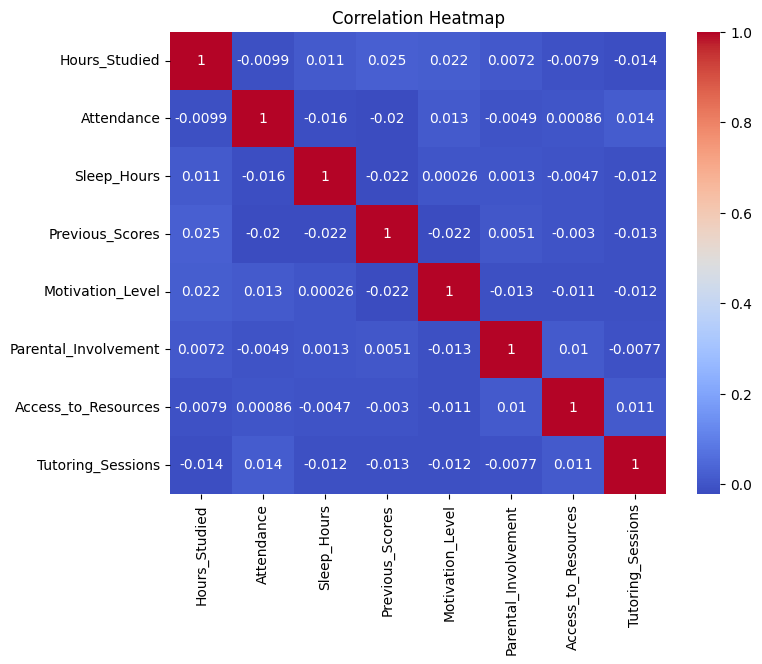

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    X.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()